In [316]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import csv
import re

#### Use output data from add_clinical_notes.ipynb

In [317]:
stroke_df = pd.read_csv("complete_clean_data.csv", quoting=csv.QUOTE_ALL, escapechar="\\", encoding="utf-8")
stroke_df.columns

Index(['note_id', 'subject_id', 'hadm_id', 'note_type', 'note_seq',
       'charttime', 'storetime', 'text', 'Unnamed: 0', 'icd_code', 'gender',
       'anchor_age', 'dod', 'mortality', 'admittime', 'dischtime', 'deathtime',
       'admission_type', 'race', 'marital_status', 'number_of_readmissions',
       'icd_version', 'age_group'],
      dtype='object')

#### Check marital status for possible ways to encode it

In [318]:
stroke_df["marital_status"].unique()

array(['MARRIED', 'WIDOWED', 'SINGLE', 'DIVORCED', nan], dtype=object)

In [319]:
stroke_df["marital_status"].isnull().sum()

np.int64(1187)

In [320]:
stroke_df.isnull().sum()

,0
note_id,0
subject_id,0
hadm_id,0
note_type,0
note_seq,0
charttime,0
storetime,0
text,0
Unnamed: 0,0
icd_code,0


In [321]:
stroke_df["marital_status"].value_counts()

,count
marital_status,
MARRIED,8025
SINGLE,3934
WIDOWED,3412
DIVORCED,1332


##### To fill null values in marital status, assign those with ages less than 30 as single, and those greater than 30 as married

In [322]:
stroke_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17890 entries, 0 to 17889
Data columns (total 23 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   note_id                 17890 non-null  object
 1   subject_id              17890 non-null  int64 
 2   hadm_id                 17890 non-null  int64 
 3   note_type               17890 non-null  object
 4   note_seq                17890 non-null  int64 
 5   charttime               17890 non-null  object
 6   storetime               17890 non-null  object
 7   text                    17890 non-null  object
 8   Unnamed: 0              17890 non-null  int64 
 9   icd_code                17890 non-null  object
 10  gender                  17890 non-null  object
 11  anchor_age              17890 non-null  int64 
 12  dod                     6725 non-null   object
 13  mortality               17890 non-null  int64 
 14  admittime               17890 non-null  object
 15  di

In [323]:
stroke_df["anchor_age"] = stroke_df["anchor_age"].astype(int)

In [324]:
mask = stroke_df["marital_status"].isna()
stroke_df.loc[mask, "marital_status"] = np.where(stroke_df.loc[mask, "anchor_age"] < 30,
    "SINGLE",
    "MARRIED")
stroke_df["marital_status"].value_counts()

,count
marital_status,
MARRIED,9194
SINGLE,3952
WIDOWED,3412
DIVORCED,1332


#### Check correlation of the marital_status column with the target variable

In [325]:
encoded = pd.get_dummies(stroke_df["marital_status"])
encoded["mortality"] = stroke_df["mortality"]
correlation = encoded.corr()['mortality'].sort_values(ascending=False).drop("mortality")
print(correlation)

WIDOWED     0.115855
DIVORCED   -0.024052
MARRIED    -0.036275
SINGLE     -0.050793
Name: mortality, dtype: float64


#### Plot correlation between marital status and mortality

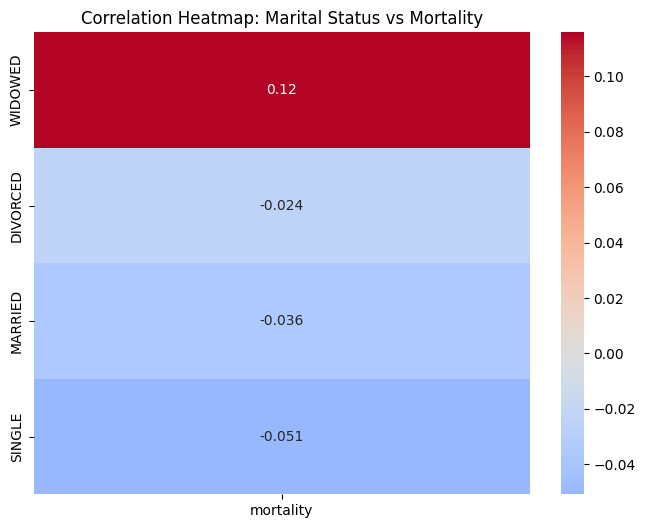

In [326]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation.to_frame(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap: Marital Status vs Mortality')
plt.savefig("marital_corr.png", dpi=500)
plt.show()

#### Split ICD codes into groups and encode into 6 classes:
1) Ischemic stroke
2) Hemorrhagic stroke
3) History of TIA
4) Ischemic stroke + history of TIA
5) Hemorrhagic stroke + History of TIA
6) Ischemic stroke + Hemorrhagic stroke

In [327]:
# Your stroke ICD codes (prefixes)
ischemic_prefixes = ["433", "434", "436", "I63", "I64"]
hemorrhagic_prefixes = ["430", "431", "432", "438", "I60", "I61", "I62", "I69"]
history_tia_prefixes = ["V1254", "Z8673"]

In [328]:
def map_icd_to_category(code):
    code = code.strip().upper()
    if any(code.startswith(p) for p in ischemic_prefixes):
        return "Ischemic"
    elif any(code.startswith(p) for p in hemorrhagic_prefixes):
        return "Hemorrhagic"
    elif any(code.startswith(p) for p in history_tia_prefixes):
        return "History of TIA"
    else:
        return None  # not relevant for classification

In [329]:
def classify_row(icd_code_str):
  codes = [c.strip() for c in icd_code_str.split(",")]

  categories = set()
  for code in codes:
      cat = map_icd_to_category(code)
      if cat:
          categories.add(cat)
  if "Ischemic" in categories and "History of TIA" in categories:
    return "Ischemic stroke + history of TIA"
  elif "Ischemic" in categories:
      return "Ischemic stroke"
  elif "Hemorrhagic" in categories and "History of TIA" in categories:
      return "Hemorrhagic stroke + history of TIA"
  elif "Hemorrhagic" in categories:
      return "Hemorrhagic stroke"
  elif "Ischemic" in categories and "Hemorrhagic" in categories:
      return "Ischemic stroke + Hemorrhagic stroke"
  elif "History of TIA" in categories:
      return "History of TIA"
  else:
      return "Other / Not classified"

In [330]:
stroke_df["stroke_class"] = stroke_df["icd_code"].apply(classify_row)

In [331]:
stroke_df["stroke_class"].value_counts()

,count
stroke_class,
Ischemic stroke,5135
History of TIA,4960
Hemorrhagic stroke,4719
Ischemic stroke + history of TIA,1931
Hemorrhagic stroke + history of TIA,1145


#### Plot correlation between stroke class and mortality

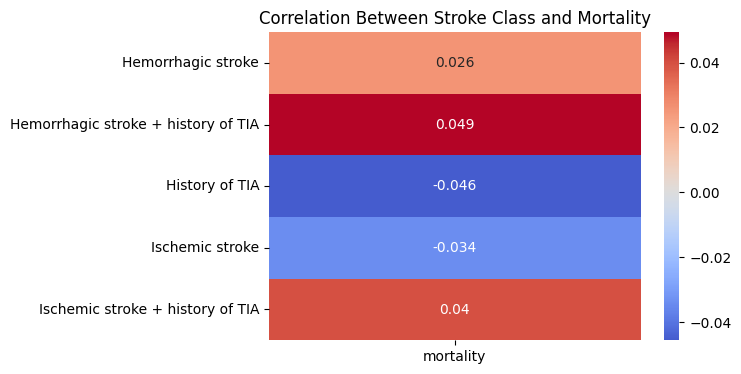

In [332]:
encoded = pd.get_dummies(stroke_df["stroke_class"])
encoded["mortality"] = stroke_df["mortality"]
corr_with_mortality = encoded.corr()["mortality"].drop("mortality")
plt.figure(figsize=(6,4))
sns.heatmap(corr_with_mortality.to_frame(), annot=True, cmap="coolwarm", center=0)
plt.title("Correlation Between Stroke Class and Mortality")
plt.savefig("stroke_class_corr.png", dpi=500, bbox_inches="tight")
plt.show()

#### Drop non-useful columns

In [333]:
stroke_df.columns

Index(['note_id', 'subject_id', 'hadm_id', 'note_type', 'note_seq',
       'charttime', 'storetime', 'text', 'Unnamed: 0', 'icd_code', 'gender',
       'anchor_age', 'dod', 'mortality', 'admittime', 'dischtime', 'deathtime',
       'admission_type', 'race', 'marital_status', 'number_of_readmissions',
       'icd_version', 'age_group', 'stroke_class'],
      dtype='object')

In [334]:
stroke_df = stroke_df.drop(["note_type", "note_seq", "Unnamed: 0"], axis=1).copy()

In [335]:
stroke_df.columns

Index(['note_id', 'subject_id', 'hadm_id', 'charttime', 'storetime', 'text',
       'icd_code', 'gender', 'anchor_age', 'dod', 'mortality', 'admittime',
       'dischtime', 'deathtime', 'admission_type', 'race', 'marital_status',
       'number_of_readmissions', 'icd_version', 'age_group', 'stroke_class'],
      dtype='object')

In [336]:
len(stroke_df)

17890

#### Import dataset omr.csv which contains patients' vital signs and their values

In [337]:
omr_data = pd.read_csv("omr.csv")
omr_data.head()

,subject_id,chartdate,seq_num,result_name,result_value
0,10000032,2180-04-27,1,Blood Pressure,110/65
1,10000032,2180-04-27,1,Weight (Lbs),94
2,10000032,2180-05-07,1,BMI (kg/m2),18.0
3,10000032,2180-05-07,1,Height (Inches),60
4,10000032,2180-05-07,1,Weight (Lbs),92.15


#### Match vital signs to patients based on subject_id and chartdate (matching chartdate to the date of admission from the admissions data or the charttime from the notes data)

In [338]:
stroke_df.head()

,note_id,subject_id,hadm_id,charttime,storetime,text,icd_code,gender,anchor_age,dod,...,admittime,dischtime,deathtime,admission_type,race,marital_status,number_of_readmissions,icd_version,age_group,stroke_class
0,10000980-DS-25,10000980,29659838,2191-07-19,2191-07-22 09:37:00,Name: ___ Unit No: ___ Admissi...,"25000,25040,25060,2724,27800,2851,28521,28749,...",F,73,2193-08-26,...,2191-07-16 14:21:00,2191-07-19 13:03:00,NaN,EW EMER.,BLACK/AFRICAN AMERICAN,MARRIED,5,10,65–74,History of TIA
1,10001877-DS-19,10001877,25679292,2149-05-27,2149-05-27 11:29:00,Name: ___ ___ No: ___ Ad...,"2252,25000,2724,4019,412,42731,4280,42833,4341...",M,89,NaN,...,2149-05-21 15:53:00,2149-05-27 13:35:00,NaN,EW EMER.,WHITE,MARRIED,0,9,85+,Ischemic stroke
2,10002430-DS-6,10002430,24648311,2129-05-02,2129-05-02 18:31:00,Name: ___ Unit No: ___ Adm...,"C439,C7951,C799,D638,D696,E7849,E785,E871,I071...",M,86,2130-01-11,...,2129-04-29 12:24:00,2129-05-02 16:37:00,NaN,DIRECT EMER.,WHITE,WIDOWED,0,10,85+,History of TIA
3,10003019-DS-23,10003019,21223482,2175-11-02,2175-11-02 22:33:00,Name: ___. Unit No: ___ Ad...,"00845,0389,135,20190,20193,20280,2724,2753,275...",M,69,NaN,...,2175-10-31 22:26:00,2175-11-02 15:30:00,NaN,EW EMER.,WHITE,MARRIED,0,9,65–74,History of TIA
4,10003299-DS-10,10003299,27373340,2183-08-01,2183-08-01 18:44:00,Name: ___ Unit No: ___ ...,"2724,3051,4011,4019,41401,43411,43491,56210,56...",F,65,2183-08-12,...,2183-07-23 20:41:00,2183-08-01 18:30:00,NaN,URGENT,BLACK/AFRICAN AMERICAN,WIDOWED,9,10,65–74,Ischemic stroke + history of TIA


In [339]:
# Convert admittime and charttime to date only
stroke_df["admittime_date"] = pd.to_datetime(stroke_df["admittime"]).dt.date
stroke_df["charttime_date"] = pd.to_datetime(stroke_df["charttime"]).dt.date

In [340]:
omr_data.columns

Index(['subject_id', 'chartdate', 'seq_num', 'result_name', 'result_value'], dtype='object')

In [341]:
# Ensure omr chartdate is also date only
omr_data["chartdate"] = pd.to_datetime(omr_data["chartdate"]).dt.date

In [342]:
# Merge using admittime-date
merge_admit = pd.merge(stroke_df, omr_data[["subject_id", "chartdate", "result_name", "result_value"]],
    left_on=["subject_id", "admittime_date"], right_on=["subject_id", "chartdate"], how="left", suffixes=("", "_admit"))

In [343]:
# Rename for admittime match
merge_admit.rename(columns={"result_name": "vital_signs_name_admit","result_value": "vital_signs_value_admit"}, inplace=True)

In [344]:
# Merge using charttime-date
merge_chart = pd.merge(stroke_df, omr_data[["subject_id", "chartdate", "result_name", "result_value"]],
    left_on=["subject_id", "charttime_date"], right_on=["subject_id", "chartdate"], how="left",suffixes=("", "_chart"))

In [345]:
# Rename for charttime match
merge_chart.rename(columns={"result_name": "vital_signs_name_chart","result_value": "vital_signs_value_chart"}, inplace=True)

In [346]:
# Combine both matches into a single dataframe
final_merge = merge_admit.copy()
final_merge["vital_signs_name"] = final_merge["vital_signs_name_admit"].fillna(merge_chart["vital_signs_name_chart"])
final_merge["vital_signs_value"] = final_merge["vital_signs_value_admit"].fillna(merge_chart["vital_signs_value_chart"])

In [347]:
final_merge.drop(columns=["vital_signs_name_admit","vital_signs_value_admit","vital_signs_name_chart",
    "vital_signs_value_chart","chartdate"], errors="ignore", inplace=True)

In [348]:
final_merge.head()

,note_id,subject_id,hadm_id,charttime,storetime,text,icd_code,gender,anchor_age,dod,...,race,marital_status,number_of_readmissions,icd_version,age_group,stroke_class,admittime_date,charttime_date,vital_signs_name,vital_signs_value
0,10000980-DS-25,10000980,29659838,2191-07-19,2191-07-22 09:37:00,Name: ___ Unit No: ___ Admissi...,"25000,25040,25060,2724,27800,2851,28521,28749,...",F,73,2193-08-26,...,BLACK/AFRICAN AMERICAN,MARRIED,5,10,65–74,History of TIA,2191-07-16,2191-07-19,BMI (kg/m2),29.6
1,10000980-DS-25,10000980,29659838,2191-07-19,2191-07-22 09:37:00,Name: ___ Unit No: ___ Admissi...,"25000,25040,25060,2724,27800,2851,28521,28749,...",F,73,2193-08-26,...,BLACK/AFRICAN AMERICAN,MARRIED,5,10,65–74,History of TIA,2191-07-16,2191-07-19,Weight (Lbs),178
2,10001877-DS-19,10001877,25679292,2149-05-27,2149-05-27 11:29:00,Name: ___ ___ No: ___ Ad...,"2252,25000,2724,4019,412,42731,4280,42833,4341...",M,89,NaN,...,WHITE,MARRIED,0,9,85+,Ischemic stroke,2149-05-21,2149-05-27,NaN,NaN
3,10002430-DS-6,10002430,24648311,2129-05-02,2129-05-02 18:31:00,Name: ___ Unit No: ___ Adm...,"C439,C7951,C799,D638,D696,E7849,E785,E871,I071...",M,86,2130-01-11,...,WHITE,WIDOWED,0,10,85+,History of TIA,2129-04-29,2129-05-02,Blood Pressure,124/67
4,10002430-DS-6,10002430,24648311,2129-05-02,2129-05-02 18:31:00,Name: ___ Unit No: ___ Adm...,"C439,C7951,C799,D638,D696,E7849,E785,E871,I071...",M,86,2130-01-11,...,WHITE,WIDOWED,0,10,85+,History of TIA,2129-04-29,2129-05-02,BMI (kg/m2),22.7


In [349]:
final_merge["vital_signs_name"].unique()

array(['BMI (kg/m2)', 'Weight (Lbs)', nan, 'Blood Pressure',
       'Height (Inches)', 'Blood Pressure Lying',
       'Blood Pressure Sitting', 'Blood Pressure Standing (3 mins)',
       'Blood Pressure Standing (1 min)', 'Blood Pressure Standing'],
      dtype=object)

#### For patients that have both weight and height data, but no BMI, calculate BMI and input it

In [350]:
len(final_merge)

26745

In [351]:
relevant_vs = ["Weight (Lbs)", "Height (Inches)"]
df_filtered = final_merge[final_merge["vital_signs_name"].isin(relevant_vs)]

# Count unique vital signs per patient
vs_count_per_patient = df_filtered.groupby("subject_id")["vital_signs_name"].nunique()

# Keep only patients who have both
patients_with_both = vs_count_per_patient[vs_count_per_patient == 2]

# Count how many patients have both
num_patients_with_both = patients_with_both.shape[0]

print("Number of patients with both Weight and Height:", num_patients_with_both)

Number of patients with both Weight and Height: 2264


In [352]:
# Filter patients missing BMI among those who have both weight and height data
patients_missing_bmi = []
for pid in patients_with_both:
    if "BMI (kg/m2)" not in final_merge[final_merge['subject_id']==pid]['vital_signs_name'].values:
        patients_missing_bmi.append(pid)

In [353]:
len(patients_missing_bmi)

2264

In [354]:
# Compute BMI and create new rows
new_rows = []
for pid in patients_missing_bmi:
    patient_data = final_merge[final_merge['subject_id'] == pid]
    weight_row = patient_data.loc[patient_data['vital_signs_name']=="Weight (Lbs)", 'vital_signs_value']
    height_row = patient_data.loc[patient_data['vital_signs_name']=="Height (Inches)", 'vital_signs_value']

    if not weight_row.empty and not height_row.empty:
        weight = float(weight_row.values[0])
        height = float(height_row.values[0])

        # BMI formula: kg/m^2
        bmi_value = (weight * 0.453592) / ((height * 0.0254) ** 2)

        # Copy a row template to keep other columns
        row_template = patient_data.iloc[0].copy()
        row_template['vital_signs_name'] = "BMI (kg/m2)"
        row_template['vital_signs_value'] = round(bmi_value, 2)

        new_rows.append(row_template)

In [355]:
len(new_rows)

0

#### There's no overlap between patients who have both weight and height information and those missing BMI values

In [356]:
# Append new rows to original dataframe
final_merge = pd.concat([final_merge, pd.DataFrame(new_rows)], ignore_index=True)

In [357]:
len(final_merge)

26745

#### Rename variants or blood pressure as "Blood Pressure"

In [358]:
bp_variations = ["Blood Pressure Lying", "Blood Pressure Sitting",
    "Blood Pressure Standing (3 mins)", "Blood Pressure Standing (1 min)",
    "Blood Pressure Standing"]
final_merge["vital_signs_name"] = final_merge["vital_signs_name"].replace(bp_variations, "Blood Pressure")

#### Keep only "BMI (kg/m2)" and "Blood Pressure" as vital signs

In [359]:
allowed = ["BMI (kg/m2)", "Blood Pressure"]

In [360]:
final_merge["vital_signs_name"] = final_merge["vital_signs_name"].where(final_merge["vital_signs_name"].isin(allowed), np.nan)

In [361]:
len(final_merge)

26745

In [362]:
final_merge["vital_signs_name"].isnull().sum()

np.int64(21887)

#### There are many null values. But before dealing with that, put BMI and blood pressure in separate columns

In [363]:
# Pivot so each vital sign becomes a column
pivoted = (final_merge.pivot_table(index=["subject_id", "admittime", "charttime"], columns="vital_signs_name",
                                   values="vital_signs_value",aggfunc="first").reset_index())

In [364]:
pivoted

vital_signs_name,subject_id,admittime,charttime,BMI (kg/m2),Blood Pressure
0,10000980,2191-07-16 14:21:00,2191-07-19,29.6,NaN
1,10002430,2129-04-29 12:24:00,2129-05-02,22.7,124/67
2,10003019,2175-10-31 22:26:00,2175-11-02,25.2,110/68
3,10012853,2177-11-03 09:30:00,2177-11-04,26.1,NaN
4,10013600,2172-08-17 16:40:00,2172-08-18,20.5,NaN
...,...,...,...,...,...
4339,19986309,2117-06-01 02:45:00,2117-06-01,24.6,NaN
4340,19986439,2152-01-10 02:51:00,2152-01-11,25.2,NaN
4341,19986810,2172-05-29 10:30:00,2172-06-04,0.2,NaN
4342,19992202,2153-02-26 00:48:00,2153-03-02,28.7,NaN


In [365]:
# Rename columns
pivoted = pivoted.rename(columns={
    "BMI (kg/m2)": "bmi",
    "Blood Pressure": "blood_pressure"})

In [366]:
stroke_df.columns

Index(['note_id', 'subject_id', 'hadm_id', 'charttime', 'storetime', 'text',
       'icd_code', 'gender', 'anchor_age', 'dod', 'mortality', 'admittime',
       'dischtime', 'deathtime', 'admission_type', 'race', 'marital_status',
       'number_of_readmissions', 'icd_version', 'age_group', 'stroke_class',
       'admittime_date', 'charttime_date'],
      dtype='object')

In [367]:
# Merge back into stroke_df
stroke_data = stroke_df.drop(columns=["admittime_date", "charttime_date"])
stroke_data = stroke_df.merge(pivoted, on=["subject_id", "admittime", "charttime"], how="left")

In [368]:
len(stroke_data)

17890

In [369]:
stroke_data.head()

,note_id,subject_id,hadm_id,charttime,storetime,text,icd_code,gender,anchor_age,dod,...,race,marital_status,number_of_readmissions,icd_version,age_group,stroke_class,admittime_date,charttime_date,bmi,blood_pressure
0,10000980-DS-25,10000980,29659838,2191-07-19,2191-07-22 09:37:00,Name: ___ Unit No: ___ Admissi...,"25000,25040,25060,2724,27800,2851,28521,28749,...",F,73,2193-08-26,...,BLACK/AFRICAN AMERICAN,MARRIED,5,10,65–74,History of TIA,2191-07-16,2191-07-19,29.6,NaN
1,10001877-DS-19,10001877,25679292,2149-05-27,2149-05-27 11:29:00,Name: ___ ___ No: ___ Ad...,"2252,25000,2724,4019,412,42731,4280,42833,4341...",M,89,NaN,...,WHITE,MARRIED,0,9,85+,Ischemic stroke,2149-05-21,2149-05-27,NaN,NaN
2,10002430-DS-6,10002430,24648311,2129-05-02,2129-05-02 18:31:00,Name: ___ Unit No: ___ Adm...,"C439,C7951,C799,D638,D696,E7849,E785,E871,I071...",M,86,2130-01-11,...,WHITE,WIDOWED,0,10,85+,History of TIA,2129-04-29,2129-05-02,22.7,124/67
3,10003019-DS-23,10003019,21223482,2175-11-02,2175-11-02 22:33:00,Name: ___. Unit No: ___ Ad...,"00845,0389,135,20190,20193,20280,2724,2753,275...",M,69,NaN,...,WHITE,MARRIED,0,9,65–74,History of TIA,2175-10-31,2175-11-02,25.2,110/68
4,10003299-DS-10,10003299,27373340,2183-08-01,2183-08-01 18:44:00,Name: ___ Unit No: ___ ...,"2724,3051,4011,4019,41401,43411,43491,56210,56...",F,65,2183-08-12,...,BLACK/AFRICAN AMERICAN,WIDOWED,9,10,65–74,Ischemic stroke + history of TIA,2183-07-23,2183-08-01,NaN,NaN


In [370]:
print("Number of null bmi values: ", stroke_data["bmi"].isnull().sum())
print("Number of null blood pressure values: ", stroke_data["blood_pressure"].isnull().sum())

Number of null bmi values:  13706
Number of null blood pressure values:  17394


#### Load the data with NER entities and filter to get only those rows

In [371]:
ner_data = pd.read_excel("ner_stroke_notes_full.xlsx")

In [372]:
ner_data.head()

,subject_id,hadm_id,charttime,storetime,gender,anchor_age,dod,mortality,admittime,dischtime,deathtime,admission_type,race,number_of_readmissions,icd_code,icd_version,age_group,entities
0,10081794,20515779,2161-10-28,2161-10-28 08:25:00,F,67.0,NaT,0.0,2161-10-21 01:53:00,2161-10-28 15:15:00,NaT,SURGICAL SAME DAY ADMISSION,WHITE,1.0,V1254,9.0,65â€“74,"{'entities': ['12 hr: OTHER', 'Tablet: OTHER',..."
1,10083062,25149849,2171-11-03,2171-11-03 17:00:00,F,71.0,NaT,0.0,2171-10-31 22:48:00,2171-11-03 19:13:00,NaT,EW EMER.,WHITE,0.0,V1254,9.0,65â€“74,"{'entities': ['300 mg: OTHER', 'breath: OTHER'..."
2,10085941,26855473,2142-03-21,2142-03-21 11:09:00,F,82.0,2142-04-18,1.0,2142-03-17 18:15:00,2142-03-21 13:30:00,NaT,EW EMER.,BLACK/AFRICAN AMERICAN,0.0,43889,9.0,75â€“84,"{'entities': ['Lower extremity: OTHER', 'legs:..."
3,10086861,20684606,2131-11-21,2131-11-22 11:42:00,F,68.0,NaT,0.0,2131-11-20 21:10:00,2131-11-21 18:20:00,NaT,EW EMER.,WHITE,0.0,43491,9.0,65â€“74,"{'entities': ['50 mg daily: DOSAGE', 'tracing:..."
4,10087053,27246053,2176-01-07,2176-01-07 19:26:00,F,43.0,NaT,0.0,2176-01-07 02:48:00,2176-01-07 19:30:00,NaT,EU OBSERVATION,WHITE,0.0,4373,9.0,18â€“44,"{'entities': ['hours: OTHER', 'Levothyroxine S..."


In [373]:
len(ner_data)

1573

In [374]:
ml_data = stroke_data.merge(ner_data[["subject_id", "hadm_id", "entities"]],
                            on=["subject_id", "hadm_id"],how="inner")

In [375]:
len(ml_data)

1517

In [376]:
ml_data.head()

,note_id,subject_id,hadm_id,charttime,storetime,text,icd_code,gender,anchor_age,dod,...,marital_status,number_of_readmissions,icd_version,age_group,stroke_class,admittime_date,charttime_date,bmi,blood_pressure,entities
0,10081794-DS-11,10081794,20515779,2161-10-28,2161-10-28 08:25:00,Name: ___ Unit No: ___ Admiss...,"2753,27541,2851,4019,42731,7213,72190,72252,73...",F,67,NaN,...,DIVORCED,1,9,65–74,History of TIA,2161-10-21,2161-10-28,27.5,NaN,"{'entities': ['12 hr: OTHER', 'Tablet: OTHER',..."
1,10083062-DS-10,10083062,25149849,2171-11-03,2171-11-03 17:00:00,Name: ___ Unit No: ___...,"25060,2749,27651,2809,29572,311,3572,4019,4280...",F,71,NaN,...,SINGLE,0,9,65–74,History of TIA,2171-10-31,2171-11-03,NaN,NaN,"{'entities': ['300 mg: OTHER', 'breath: OTHER'..."
2,10085941-DS-7,10085941,26855473,2142-03-21,2142-03-21 11:09:00,Name: ___ Unit No: ___ ...,"2720,2948,3558,4011,42731,4280,42832,43889,459...",F,82,2142-04-18,...,SINGLE,0,9,75–84,Hemorrhagic stroke,2142-03-17,2142-03-21,NaN,NaN,"{'entities': ['Lower extremity: OTHER', 'legs:..."
3,10086861-DS-10,10086861,20684606,2131-11-21,2131-11-22 11:42:00,Name: ___ Unit No: __...,"2724,30000,4019,412,41401,43491,4379,72887,781...",F,68,NaN,...,MARRIED,0,9,65–74,Ischemic stroke,2131-11-20,2131-11-21,NaN,NaN,"{'entities': ['50 mg daily: DOSAGE', 'tracing:..."
4,10087948-DS-7,10087948,21731314,2115-04-25,2115-04-25 16:42:00,Name: ___ Unit No: ___ ...,"1970,1977,1985,2449,2724,2762,27650,28521,2852...",M,81,2115-05-14,...,MARRIED,0,9,75–84,History of TIA,2115-04-21,2115-04-25,NaN,NaN,"{'entities': ['Prednisone: MEDICATION', '8: LA..."


In [377]:
ml_data.to_csv("ml_data.csv", index=False)

In [378]:
ml_data[['bmi', 'blood_pressure']].isna().sum()

,0
bmi,1156
blood_pressure,1488


#### Fill in missing BMI and Blood Pressure values from the clinical notes

In [386]:
# Function to extract BMI from clinical notes
def extract_bmi(text):
    match = re.search(r'\bBMI[:\s]*([0-9]+(?:\.[0-9]+)?)', text, re.IGNORECASE)
    return float(match.group(1)) if match else np.nan

In [387]:
# Function to extract blood pressure from clinical notes
def extract_bp(text):
    match = re.search(r'\b(?:BP|Blood Pressure)[:\s]*([0-9]{2,3}/[0-9]{2,3})', text, re.IGNORECASE)
    return match.group(1) if match else np.nan

In [381]:
# Fill missing values
ml_data["bmi"] = ml_data.apply(lambda row: extract_bmi(row["text"]) if pd.isna(row['bmi']) else row['bmi'], axis=1)
ml_data["blood_pressure"] = ml_data.apply(lambda row: extract_bp(row["text"]) if pd.isna(row['blood_pressure']) else row['blood_pressure'], axis=1)

In [382]:
ml_data[['bmi', 'blood_pressure']].isna().sum()

,0
bmi,1150
blood_pressure,672


In [383]:
ml_data.columns

Index(['note_id', 'subject_id', 'hadm_id', 'charttime', 'storetime', 'text',
       'icd_code', 'gender', 'anchor_age', 'dod', 'mortality', 'admittime',
       'dischtime', 'deathtime', 'admission_type', 'race', 'marital_status',
       'number_of_readmissions', 'icd_version', 'age_group', 'stroke_class',
       'admittime_date', 'charttime_date', 'bmi', 'blood_pressure',
       'entities'],
      dtype='object')

In [384]:
final_data = ml_data.rename(columns={"icd_code": "icd_codes"})
final_data.columns

Index(['note_id', 'subject_id', 'hadm_id', 'charttime', 'storetime', 'text',
       'icd_codes', 'gender', 'anchor_age', 'dod', 'mortality', 'admittime',
       'dischtime', 'deathtime', 'admission_type', 'race', 'marital_status',
       'number_of_readmissions', 'icd_version', 'age_group', 'stroke_class',
       'admittime_date', 'charttime_date', 'bmi', 'blood_pressure',
       'entities'],
      dtype='object')

In [385]:
ml_data.to_csv("final_data_tfn.csv")